In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Librerías de Procesamiento de Lenguaje Natural (NLP)
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
import re # Para expresiones regulares (limpiar símbolos)

# Recursos lingüísticos necesarios para el español
nltk.download('punkt')           # Tokenizador
nltk.download('stopwords') 
nltk.download('punkt_tab') # Palabras comunes sin valor semántico

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jonba\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jonba\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jonba\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
text = os.path.join('Datos','transformados', "MadridPalacioReal_booking_reviews_todas.csv")
df = pd.read_csv(text)

In [3]:
def clean_text_round(text):
    text = re.sub('\r', '', text)
    text = re.sub('\n', ' ', text)
    text = re.sub('Â', '', text)
    text = re.sub('\u200a', '', text)
    return text

In [4]:
df['full_review'] = df['positive'].fillna('') + ' ' + df['negative'].fillna('')

In [5]:
df['full_review'] = df['full_review'].apply(clean_text_round)

In [6]:
lines = " ".join(df['full_review'])

In [7]:
sentences = sent_tokenize(lines)
total_documents = len(sentences)


In [8]:
documents_tokens = []

for sentence in sentences:
    tokens = word_tokenize(sentence, language='spanish')
    documents_tokens.append(tokens)


In [9]:
all_words = []

for doc in documents_tokens:
    all_words.extend(doc)

all_words = [w.lower() for w in all_words if w.isalpha()]



In [10]:
from sklearn.feature_extraction.text import CountVectorizer

# Stopwords en español
stop_words = stopwords.words('spanish')

vectorizer = CountVectorizer(
    stop_words=stop_words,
    lowercase=True
)

X = vectorizer.fit_transform(sentences)


In [11]:
X.shape


(149, 792)

In [12]:
tdm = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)


In [13]:
word_freq = tdm.sum(axis=0).sort_values(ascending=False)
print(word_freq.head(10))


ubicación      33
habitación     20
bien           17
apartamento    16
si             15
cómodo         13
ruido          13
cama           12
personal       11
limpieza       10
dtype: int64


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

stop_words = stopwords.words('spanish')

tf_vectorizer = TfidfVectorizer(
    use_idf=False,      # solo TF
    norm='l1',          # normaliza por documento
    stop_words=stop_words,  # quita stopwords
    lowercase=True
)

X_tf = tf_vectorizer.fit_transform(sentences)

# Convertir a DataFrame
tf_matrix = pd.DataFrame(
    X_tf.toarray(),
    columns=tf_vectorizer.get_feature_names_out()
)

print(tf_matrix.head())


         10   12   15   16  200   22        30  700     abajo  abierta  ...  \
0  0.000000  0.0  0.0  0.0  0.0  0.0  0.000000  0.0  0.000000      0.0  ...   
1  0.000000  0.0  0.0  0.0  0.0  0.0  0.083333  0.0  0.000000      0.0  ...   
2  0.014493  0.0  0.0  0.0  0.0  0.0  0.000000  0.0  0.014493      0.0  ...   
3  0.000000  0.0  0.0  0.0  0.0  0.0  0.000000  0.0  0.000000      0.0  ...   
4  0.000000  0.0  0.0  0.0  0.0  0.0  0.000000  0.0  0.000000      0.0  ...   

   vuelta  vía  whatsapp  zona  zonas  ático  última  último  única  único  
0     0.0  0.0       0.0   0.0    0.0    0.0     0.0     0.0    0.0    0.0  
1     0.0  0.0       0.0   0.0    0.0    0.0     0.0     0.0    0.0    0.0  
2     0.0  0.0       0.0   0.0    0.0    0.0     0.0     0.0    0.0    0.0  
3     0.0  0.0       0.0   0.0    0.0    0.0     0.0     0.0    0.0    0.0  
4     0.0  0.0       0.0   0.0    0.0    0.0     0.0     0.0    0.0    0.0  

[5 rows x 792 columns]


In [15]:
# Convertir a binario: 1 si aparece, 0 si no
binary_matrix = (tf_matrix > 0).astype(int)

# Sumar por columna → cuántas frases contienen cada palabra
word_in_sentences = binary_matrix.sum(axis=0)
word_in_sentences_sorted = word_in_sentences.sort_values(ascending=False)
print(word_in_sentences_sorted.head(10))


ubicación      25
habitación     18
bien           16
apartamento    14
cómodo         13
si             13
ruido          12
cama           10
limpieza       10
personal       10
dtype: int64


In [16]:
N = tf_matrix.shape[0]

idf_vector = np.log(N / word_in_sentences)
print(idf_vector.sort_values(ascending=False).head(10))


única         5.003946
última        5.003946
12            5.003946
15            5.003946
16            5.003946
ventanales    5.003946
vas           5.003946
variado       5.003946
valorarlo     5.003946
valijas       5.003946
dtype: float64


In [17]:
tfidf_matrix0 = tf_matrix * idf_vector


In [18]:
print(tfidf_matrix0.iloc[3].sort_values(ascending=False).head(10))


completo    2.155400
desayuno    1.462252
vienen      0.000000
viajamos    0.000000
abajo       0.000000
único       0.000000
10          0.000000
12          0.000000
15          0.000000
16          0.000000
Name: 3, dtype: float64


In [19]:
sentence_scores = tfidf_matrix0.apply(
    lambda row: row[row > 0].mean(),
    axis=1
)
print(sentence_scores.sort_values(ascending=False).head(10))


43     5.003946
113    5.003946
29     4.310799
12     3.905334
106    3.058036
57     2.501973
73     2.501973
99     2.501973
127    2.501973
75     2.328686
dtype: float64


In [20]:
average_score = sentence_scores.mean()
average_score

np.float64(0.9220400566243552)

In [21]:
def _generate_summary(sentences, sentence_scores, average_score):
    summary = ''
    sentence_count = 0
    
    for i, sentence in enumerate(sentences):
        if sentence_scores.iloc[i] >= average_score:
            summary += " " + sentence
            sentence_count += 1
            
    return summary


In [22]:
summary = _generate_summary(sentences, sentence_scores, 1.3 * average_score)
print(summary)

 El desayuno es muy completo. Todo bien. Localización. No fue nuestro caso, pero algo peligrosas. Las comodidades. Que carecieran de un conversor de divisas. Mis tarjetas argentinas están monetizadas al dolar. Libere rechazaba el pago. Muy buena ubicación. Colchón cómodo. Apartamento amplio. No tiene lavavajillas. El plato de ducha pequeño. El lavabo pequeño. Las ventanas no cerraban bien. Que no hay un bote de basura en la sala de estar. la ubicación inmejorable. Incluiría plancha. La cama era genial. Que no haya baño en la recepción. Se le nota algo batallero. Regalado es caro. Los platos no estaban bien lavados. Muy tranquilo y cómodo. Es igual a lo que muestran las imágenes. Los que llevan mascotas, q lo tengan en cuenta. Esas cosas me incomodaron. El olor del cuarto de baño. Estaba todo muy limpio. Dejaron detallitos para nosotros y nuestra perrita. hace frío la. Mucho, nos encanto. Posición súper ideal, muy acogedor. Al avisar tampoco lo arreglaron. No tengo quejas del establecim

In [23]:
# opiniones negativas
neg_reviews = df['negative'].dropna()

sentences = []
for review in neg_reviews:
    sentences.extend(sent_tokenize(review, language='spanish'))

print(f"Número de frases negativas: {len(sentences)}")


Número de frases negativas: 118


In [24]:
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# Definir stopwords en español
stop_words_es = stopwords.words('spanish')

tfidf_vectorizer = TfidfVectorizer(
    stop_words=stop_words_es,  # <- nombre correcto
    lowercase=True,
    max_df=0.9,
    min_df=5,
    ngram_range=(1,2)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(sentences)


In [25]:
from sklearn.cluster import KMeans

k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(tfidf_matrix)

labels = kmeans.labels_


In [26]:
import numpy as np

# Número de palabras a mostrar por cluster
top_n = 15

# Nombres de las palabras del TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()

# Orden de importancia de cada palabra en cada cluster
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]  # de mayor a menor

# Mostrar las top 15 palabras por cluster
for i in range(k):  # k = número de clusters
    print(f"\nCluster {i} - Top {top_n} palabras clave:")
    top_words = [feature_names[ind] for ind in order_centroids[i, :top_n]]
    print(", ".join(top_words))




Cluster 0 - Top 15 palabras clave:
baño, hora, habitación, solo, si, personas, personal, ruido, ser, mejor, noche, desayuno, frío, cama, calle

Cluster 1 - Top 15 palabras clave:
bien, ser, si, solo, ruido, personal, noche, mejor, personas, hora, habitación, desayuno, frío, cama, calle

Cluster 2 - Top 15 palabras clave:
ruido, noche, apartamento, calle, si, bien, habitación, frío, personas, desayuno, baño, ser, solo, hora, mejor

Cluster 3 - Top 15 palabras clave:
cama, personal, solo, mejor, si, ser, desayuno, frío, personas, hora, apartamento, habitación, calle, noche, bien


In [27]:
from nltk.corpus import stopwords
nltk.download('stopwords')  # si no lo has hecho ya

stop_words_es = stopwords.words('spanish')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jonba\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf_vectorizer = TfidfVectorizer(
    stop_words=stop_words_es,  # <- lista de NLTK
    lowercase=True
)

# Usar las mismas frases que para K-Means
neg_sentences = sentences  # o la lista exacta usada para labels

X_tf = tf_vectorizer.fit_transform(neg_sentences)
tfidf_matrix0 = pd.DataFrame(X_tf.toarray(), columns=tf_vectorizer.get_feature_names_out())



In [29]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

top_n_words = 15
top_n_sentences = 5
k = len(np.unique(labels))

# Diccionario para nombrar clusters según interpretación de palabras
# Puedes ajustar los nombres según lo que observes
cluster_names = {
    0: "Comodidad y equipamiento",
    1: "Ubicación y accesibilidad",
    2: "Limpieza y confort",
    3: "Comodidad + ubicación"
}

for i in range(k):
    # Frases del cluster
    cluster_sentences = [sent for sent, label in zip(sentences, labels) if label == i]
    
    # TF-IDF promedio por palabra dentro del cluster
    cluster_rows = tfidf_matrix0.iloc[[j for j, l in enumerate(labels) if l == i]]
    tfidf_mean = cluster_rows.mean(axis=0)
    
    # Top palabras
    top_words = tfidf_mean.sort_values(ascending=False).head(top_n_words).index.tolist()
    
    print(f"\nCluster {i} - {cluster_names.get(i, 'Tema desconocido')}")
    print(f"Top {top_n_words} palabras: {', '.join(top_words)}")
    
    # Ejemplos de frases
    print(f"Ejemplos de frases ({top_n_sentences}):")
    for sent in cluster_sentences[:top_n_sentences]:
        print("-", sent)



Cluster 0 - Comodidad y equipamiento
Top 15 palabras: baño, recepción, ducha, olor, cuarto, ducharse, jabón, líquido, único, piezas, rotas, habian, porcelanato, valorarlo, bonita
Ejemplos de frases (5):
- En el baño a veces se filtraban olores al abrir los grifos y la ducha tenía muy muy poca presión.
- Que no haya baño en la recepción.
- En el baño un único jabón líquido muy incómodo a la hora de ducharse
- la puerta del baño tiene deja una hendija abierta Fe por los menos 1 cm, lo que da una intimidad nula.
- El baño no era cómodo, habian piezas del porcelanato rotas en el plato de la ducha.

Cluster 1 - Ubicación y accesibilidad
Top 15 palabras: bien, cerraban, platos, lavados, ventanas, alguien, utensilios, loza, equipada, sucios, cocina, lástima, equipado, lograr, duerman
Ejemplos de frases (5):
- Todo bien.
- Las ventanas no cerraban bien.
- La cocina estaba bien equipada, pero algunos utensilios y loza muy sucios.
- Los platos no estaban bien lavados.
- Que no haya NADIE para r

## Tabla de frecuencias y wordcloud y graficos

In [36]:
negative_reviews = df['negative'].dropna()
negative_reviews = negative_reviews.apply(clean_text_round)

# Unir todo el texto negativo
negative_text = " ".join(negative_reviews)

In [37]:
# Tokenizar palabras
tokens_neg = word_tokenize(negative_text, language='spanish')

# Limpiar: minúsculas, alfabéticas, sin stopwords
stop_words_es = stopwords.words('spanish')

tokens_neg_clean = [
    w.lower() for w in tokens_neg
    if w.isalpha() and w.lower() not in stop_words_es
]

In [38]:
# Tabla de frecuencias
freq_neg = pd.Series(tokens_neg_clean).value_counts()

# Convertir a DataFrame
freq_neg_df = freq_neg.reset_index()
freq_neg_df.columns = ['Palabra', 'Frecuencia']

print("\nTop 20 palabras negativas más frecuentes:")
print(freq_neg_df.head(20))


Top 20 palabras negativas más frecuentes:
        Palabra  Frecuencia
0          cama         260
1          sofá         185
2   apartamento         113
3    habitación         109
4          bien         106
5            si         103
6          baño          88
7      incómodo          75
8          solo          73
9         noche          65
10          dos          61
11        ruido          60
12     personas          58
13     limpieza          58
14        falta          52
15     personal          50
16       cocina          50
17        check          48
18            q          47
19       dormir          47


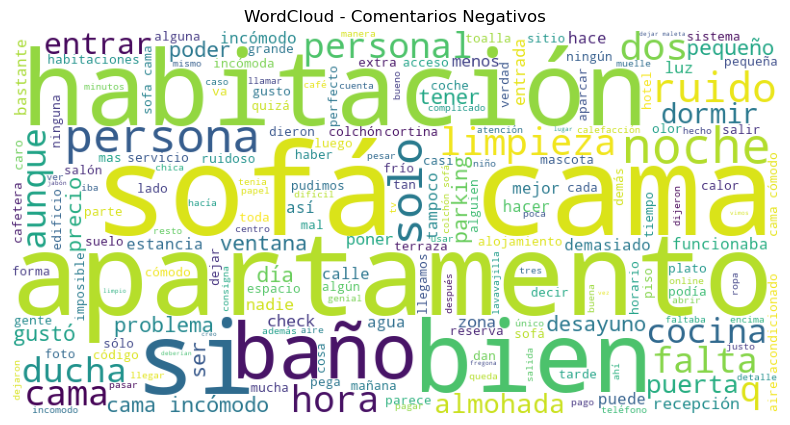

In [39]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(" ".join(tokens_neg_clean))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("WordCloud - Comentarios Negativos")
plt.show()

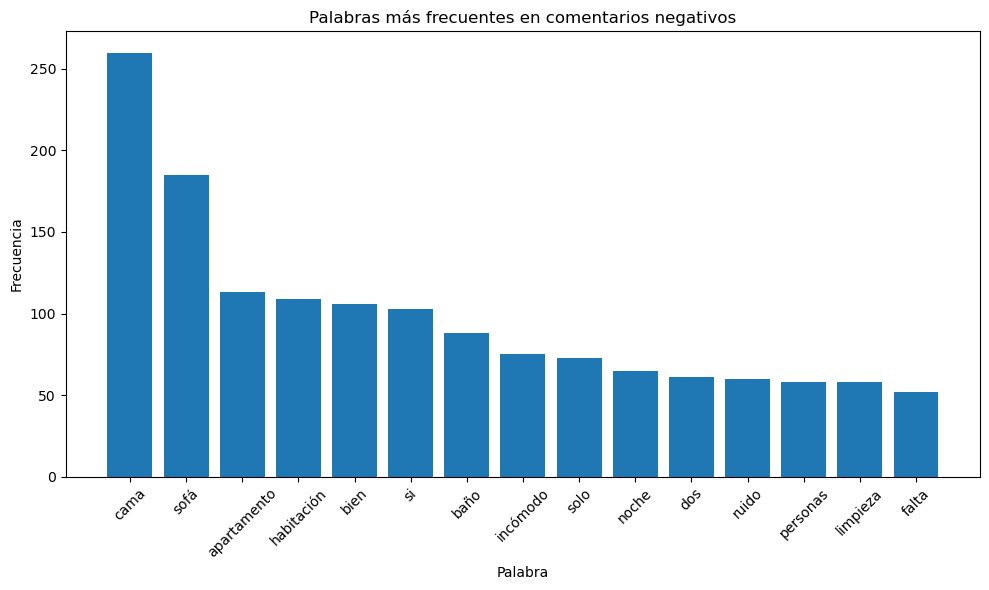

In [40]:
top_n = 15
top_words = freq_neg_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.bar(top_words['Palabra'], top_words['Frecuencia'])
plt.xticks(rotation=45)
plt.title("Palabras más frecuentes en comentarios negativos")
plt.xlabel("Palabra")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()